# Proyecto: Minería de Datos - Sistemas de Recomendación con MovieLens 20M
## Minería de Patrones y Similitud con Spark, MinHashing y LSH

In [2]:
%pip install pyspark

In [1]:
from google.colab import drive

# 1. Montar Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


---

## SETUP INICIAL: Configuración de Spark y Importaciones

### Paso 1: Configurar la sesión de Spark


In [5]:
# 2. En otra celda, importa y arranca la configuración modular refactorizada
from source.utils import config

# Configura gráficas
config.setup_visualization()
_COUNT = False
# Inicia la sesión Spark y recibe los hiperparámetros
spark, parametros = config.init_spark("full")
print("lsh_configurations:")
print(parametros["lsh_configurations"])

--------------------------------------------------
✓ Spark sesión inicializada
✓ Spark version: 4.0.2
✓ Perfil activo: full
✓ Aceleración GPU (cuDF/cuML): NO DISPONIBLE
--------------------------------------------------
lsh_configurations:
lsh_configurations:
[(120, 10), (150, 8), (240, 5), (300, 4), (600, 2)]


### Paso 2: Cargar los datos del dataset MovieLens 20M

Cargaremos los archivos CSV principales en DataFrames de Spark para procesarlos de manera distribuida:
- **ratings.csv:** Contiene todas las calificaciones
- **movies.csv:** Información sobre películas y géneros
- **tags.csv:** Tags asignados por usuarios

In [6]:
from source.utils import data_loader

# 1. Definir tu ruta
dataset_path = '/content/drive/MyDrive/Ciclo 10/Data Mining/Dataset'

# 2. Cargar todo en una sola línea llamando al nuevo módulo
ratings_df, movies_df, tags_df = data_loader.load_datasets(spark, dataset_path, verbose=True)

# Si _COUNT es True ejecuta la celda
if _COUNT:
  print("Total ratings:", ratings_df.count())

Cargando datos desde: /content/drive/MyDrive/Ciclo 10/Data Mining/Dataset ...

✓ Ratings DataFrame Schema:
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: float (nullable = true)
 |-- timestamp: long (nullable = true)

--------------------------------------------------
✓ Movies DataFrame Schema:
root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)

--------------------------------------------------
✓ Tags DataFrame Schema:
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- tag: string (nullable = true)
 |-- timestamp: long (nullable = true)

✓ Todos los archivos listos como DataFrames (Lazy Evaluation)


---

# PARTE I: PREPROCESAMIENTO Y EXPLORACIÓN DE DATOS (EDA)

## Introducción a la Parte I

En esta sección realizaremos:
1. **Limpieza y preprocesamiento:** Eliminar nulos, inconsistencias y duplicados
2. **Normalización:** Unificar etiquetas de géneros
3. **Transformación:** Convertir ratings a escala binaria (like/dislike)
4. **Exploración:** Análisis estadístico y visualización del dataset

Estas operaciones se ejecutarán con **Spark SQL y DataFrames** para aprovechar el procesamiento distribuido en el dataset completo.

---

## 1.1 PREPROCESAMIENTO

### Paso 1: Detectar y manejar valores nulos

In [7]:
from source.utils.preprocessing import analyze_and_clean_nulls

# Agrupas los DataFrames originales en un diccionario
dfs_to_clean = {
    "Ratings": ratings_df,
    "Movies": movies_df,
    "Tags": tags_df
}

# La función se encarga de todo el procesamiento en un solo paso
# NOTA: Cambiar verbose=False evita los counts
cleaned_dataframes = analyze_and_clean_nulls(dfs_to_clean, verbose=_COUNT)

# Recuperas tus DataFrames ya limpios
ratings_clean = cleaned_dataframes["Ratings"]
movies_clean = cleaned_dataframes["Movies"]
tags_clean = cleaned_dataframes["Tags"]

/content/source/utils/preprocessing.py:121: SyntaxWarning: invalid escape sequence '\|'
  explode(split(col("genres"), "\|")).alias("genre")
/content/source/utils/preprocessing.py:162: SyntaxWarning: invalid escape sequence '\|'
  genres_before = movies_df.select(explode(split(col("genres"), "\|")).alias("genre")).groupBy("genre").count()
/content/source/utils/preprocessing.py:163: SyntaxWarning: invalid escape sequence '\|'
  genres_after = movies_normalized.select(explode(split(col("genres"), "\|")).alias("genre")).groupBy("genre").count()


### Paso 2: Eliminar duplicados

In [8]:
from source.utils.preprocessing import remove_duplicates
dedupe_config = {
    "Ratings": ["userId", "movieId"],
    "Movies": ["movieId"],
    "Tags": ["userId", "movieId", "tag"]
}

# 4. Aplicar función deduplicadora
dfs_final = remove_duplicates(cleaned_dataframes, dedupe_columns=dedupe_config, verbose=_COUNT)

# Recuperas tus DataFrames listos:
ratings_clean = dfs_final["Ratings"]
movies_clean = dfs_final["Movies"]
tags_clean = dfs_final["Tags"]

### Paso 3: Transformar ratings a escala binaria

**Justificación de la escala binaria:**
- Las similitudes de Jaccard y MinHashing funcionan mejor con conjuntos binarios
- Un threshold de 3.5 estrella es un punto de corte razonable: separa "películas bien calificadas" de las mediocres
- Facilita la interpretación: una película es "liked" (≥3.5) o "disliked" (<3.5)

In [9]:
from source.utils.preprocessing import convert_to_binary_ratings


ratings_binary = convert_to_binary_ratings(
    ratings_clean,
    rating_threshold=3.5,
    verbose=_COUNT
)

### Paso 4: Normalizar géneros

**Justificación:**
- MovieLens contiene variaciones inconsistentes en géneros (e.g., "Sci-Fi" vs "Science Fiction", mayúsculas inconsistentes)
- La normalización asegura que análisis posteriores agrupen correctamente películas del mismo género
- Eliminamos géneros especiales (IMAX, no-genres) que no representan géneros reales


In [10]:
%pip install nltk

In [11]:
from source.utils.preprocessing import normalize_genres

movies_normalized = normalize_genres(spark, movies_clean, verbose=_COUNT)


---

## 1.2 EXPLORACIÓN DE DATOS (EDA)

### Paso 1: Distribución de calificaciones originales

In [12]:
RATING_THRESHOLD =3.5

In [16]:
from source.utils.EDA import get_rating_distribution_data, plot_rating_distribution, plot_rating_share, plot_binary_distribution

import os
os.makedirs("img", exist_ok=True)

# 1. Extraer los datos a Pandas y mostrar métricas
rating_dist_pd = get_rating_distribution_data(ratings_clean, verbose=True)

DISTRIBUCIÓN DE RATINGS
Distribución:
  Rating 0.5: 239,125 (1.20%)
  Rating 1.0: 680,732 (3.40%)
  Rating 1.5: 279,252 (1.40%)
  Rating 2.0: 1,430,997 (7.15%)
  Rating 2.5: 883,398 (4.42%)
  Rating 3.0: 4,291,193 (21.46%)
  Rating 3.5: 2,200,156 (11.00%)
  Rating 4.0: 5,561,926 (27.81%)
  Rating 4.5: 1,534,824 (7.67%)
  Rating 5.0: 2,898,660 (14.49%)

ESTADÍSTICAS DESCRIPTIVAS:
  Total: 20000263.00
  Media: 3.53
  Desv_Est: 1.05
  Mínimo: 0.50
  Máximo: 5.00
  Q1: 3.00
  Mediana: 3.50
  Q3: 4.00



✓ Gráfica guardada exitosamente en: img/distribucion_ratings.png


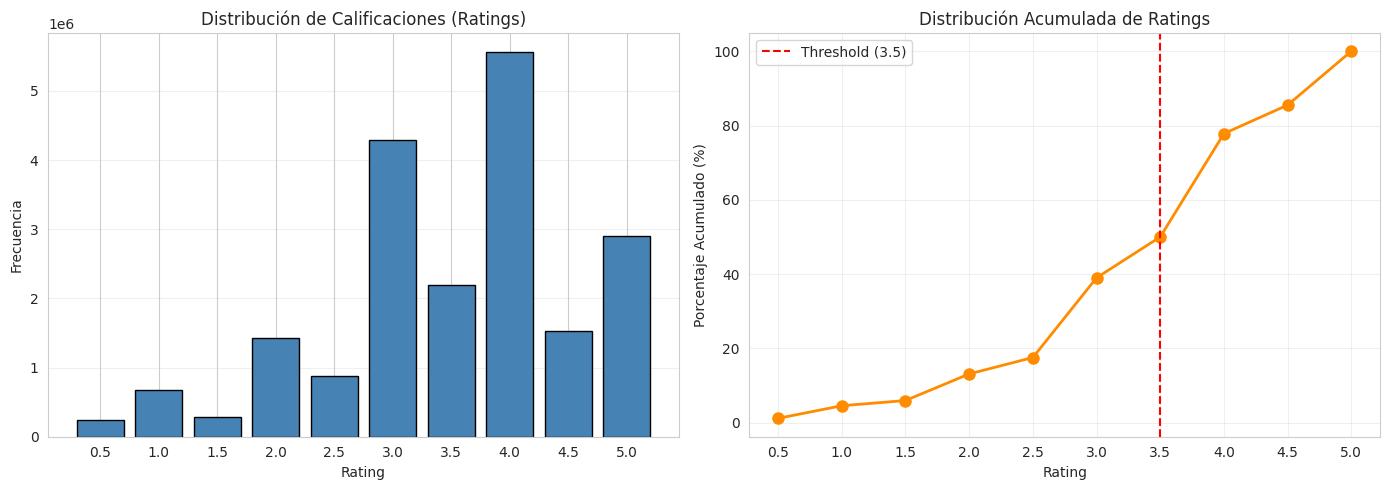

In [17]:
# 2. Histograma y acumulado
plot_rating_distribution(
    rating_dist_pd, 
    rating_threshold=RATING_THRESHOLD, 
    save_path="img/distribucion_ratings.png"
)


✓ Gráfica guardada exitosamente en: img/share_ratings.png


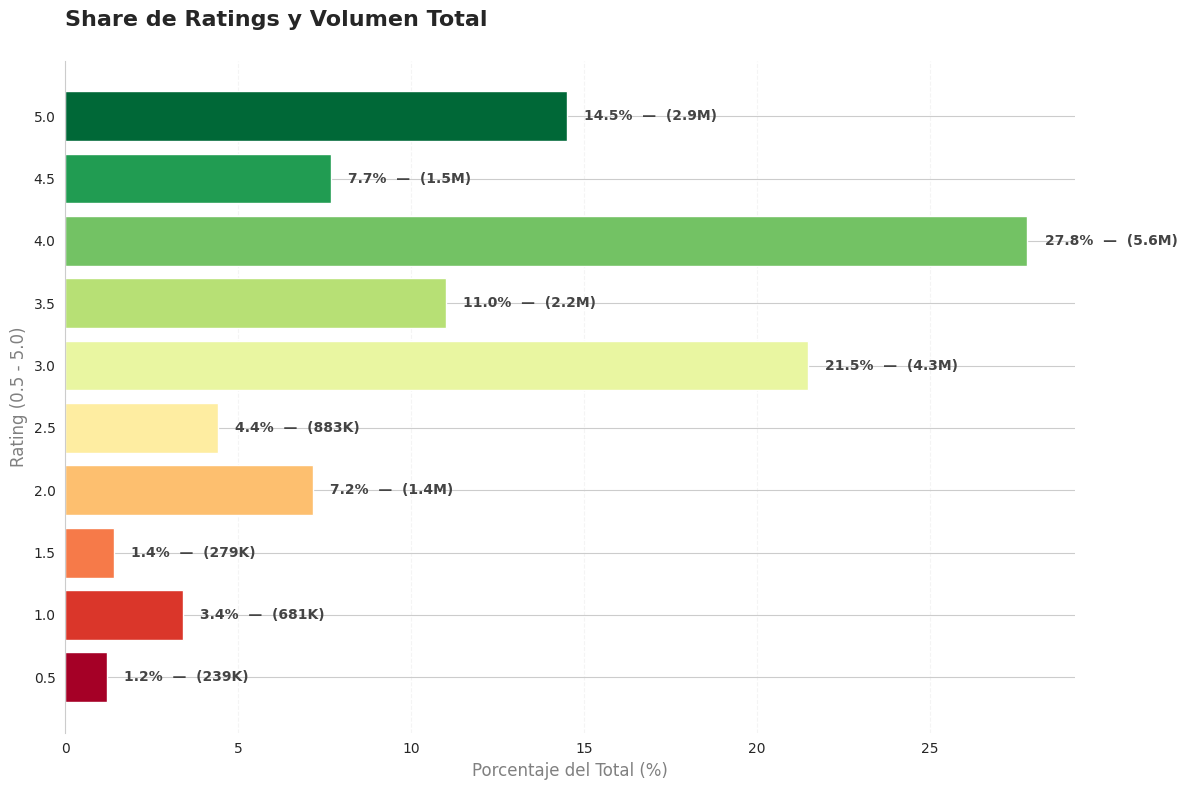

In [18]:
# 3. Share de ratings
plot_rating_share(
    rating_dist_pd, 
    save_path="img/share_ratings.png"
)

### Distribución después de la normalización binaria


✓ Gráfica guardada exitosamente en: img/distribucion_binaria.png


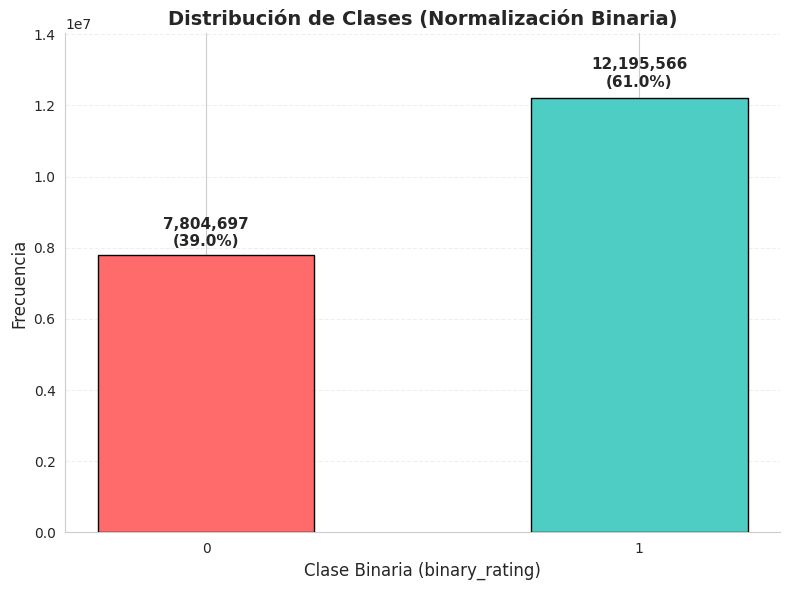

In [20]:
# 4. Distribución Binaria
plot_binary_distribution(
    ratings_binary,
    label_col='binary_rating', # Actualizado al nombre real de la columna binaria
    save_path="img/distribucion_binaria.png"
)

### Paso 2: Análisis de ratings por usuario

In [ ]:
from source.utils.EDA import get_user_activity_data, plot_user_activity_distribution, plot_user_activity_boxplot, plot_user_activity_pareto

# 1. Extraer los datos de actividad por usuario y mostrar estadísticas
ratings_per_user_pd = get_user_activity_data(ratings_clean, user_col="userId", verbose=True)

ANÁLISIS DE RATINGS POR USUARIO
Número de usuarios: 138,493
Media de ratings por usuario: 144.41
Desviación estándar: 230.27
Mínimo: 20
Máximo: 9254
Mediana: 68

TOP 10 USUARIOS MÁS ACTIVOS:
  Usuario 118205: 9254 ratings
  Usuario 8405: 7515 ratings
  Usuario 82418: 5646 ratings
  Usuario 121535: 5520 ratings
  Usuario 125794: 5491 ratings
  Usuario 74142: 5447 ratings
  Usuario 34576: 5356 ratings
  Usuario 131904: 5330 ratings
  Usuario 83090: 5169 ratings
  Usuario 59477: 4988 ratings



✓ Gráfica guardada exitosamente en: img/user_activity_dist.png


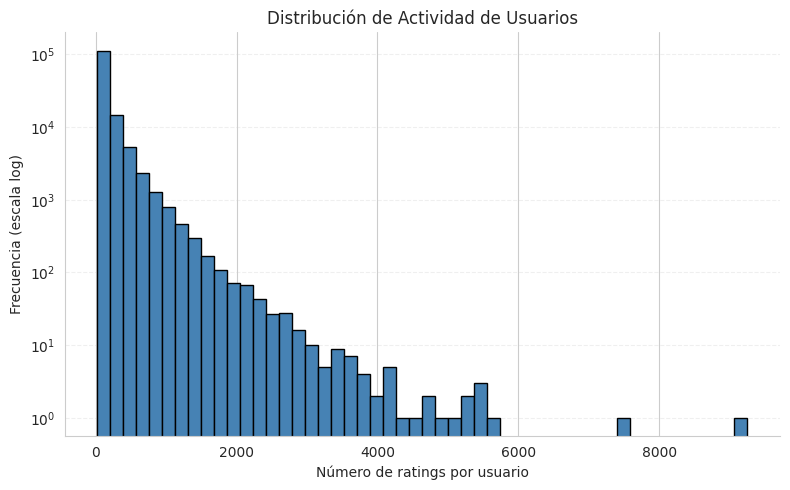

In [25]:
# 2. Histograma de distribución (escala logarítmica)
plot_user_activity_distribution(ratings_per_user_pd, save_path="img/user_activity_dist.png")


✓ Gráfica guardada exitosamente en: img/user_activity_boxplot.png


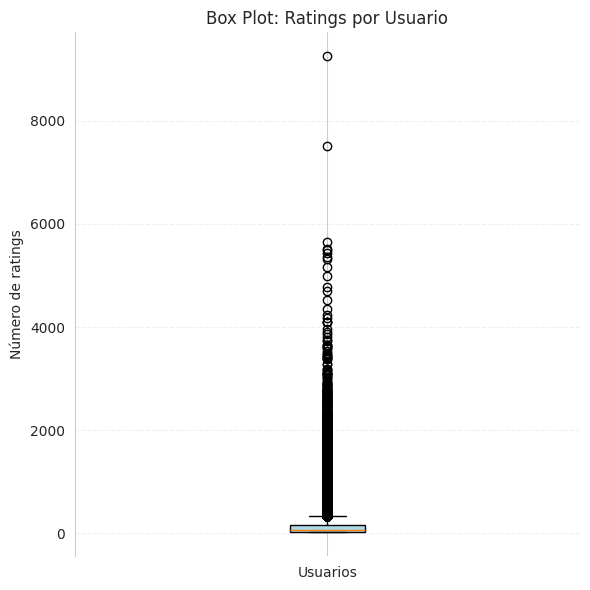


- La actividad de usuarios es altamente desigual: pocos usuarios concentran muchos ratings y la mayoría participa poco.
- La escala logarítmica y el boxplot evidencian una cola larga típica en sistemas de recomendación.


In [26]:
# 3. Box plot de actividad de usuarios
plot_user_activity_boxplot(ratings_per_user_pd, save_path="img/user_activity_boxplot.png")

print("\n- La actividad de usuarios es altamente desigual: pocos usuarios concentran muchos ratings y la mayoría participa poco.")
print("- La escala logarítmica y el boxplot evidencian una cola larga típica en sistemas de recomendación.")


✓ Gráfica guardada exitosamente en: img/user_activity_pareto.png


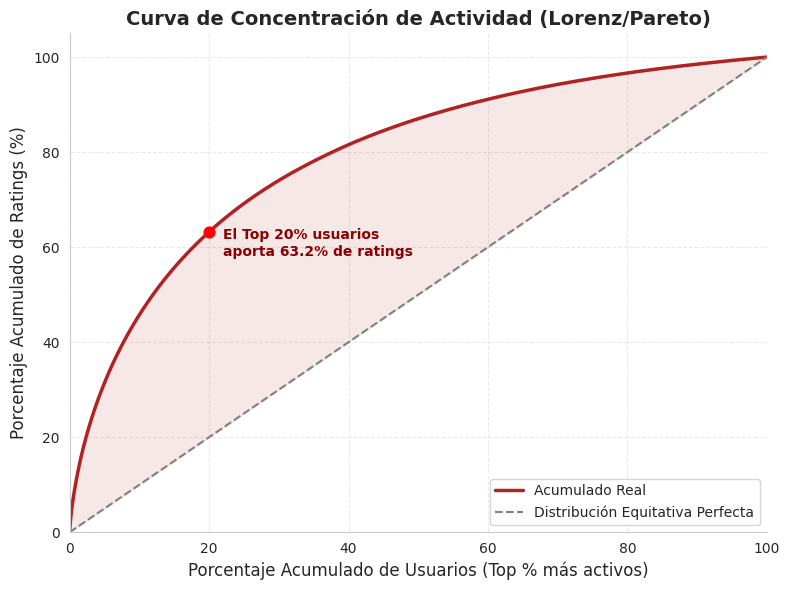


- La Curva de concentración nos ayuda a entender el sesgo real del Long-tail en sistemas de recomendación.


In [35]:
# 4. Curva de Pareto / Lorenz
plot_user_activity_pareto(ratings_per_user_pd, save_path="img/user_activity_pareto.png")

print("\n- La Curva de concentración nos ayuda a entender el sesgo real del Long-tail en sistemas de recomendación.")

In [37]:
from source.utils.EDA import get_movie_activity_data, plot_movie_popularity_distribution, plot_popularity_vs_rating_hexbin

# 1. Extraer datos del análisis y la estadística
movie_activity_pd = get_movie_activity_data(ratings_clean, movies_clean, verbose=True)

ANÁLISIS DE RATINGS POR PELÍCULA
Número de películas: 26,744
Media de ratings por película: 747.84
Desviación estándar:       3085.82
Mínimo:                    1
Máximo:                    67310
Mediana:                   18

TOP 10 PELÍCULAS MÁS CALIFICADAS:
  Pulp Fiction (1994): 67310 ratings (avg: 4.17)
  Forrest Gump (1994): 66172 ratings (avg: 4.03)
  Shawshank Redemption, The (1994): 63366 ratings (avg: 4.45)
  Silence of the Lambs, The (1991): 63299 ratings (avg: 4.18)
  Jurassic Park (1993): 59715 ratings (avg: 3.66)
  Star Wars: Episode IV - A New Hope (1977): 54502 ratings (avg: 4.19)
  Braveheart (1995): 53769 ratings (avg: 4.04)
  Terminator 2: Judgment Day (1991): 52244 ratings (avg: 3.93)
  Matrix, The (1999): 51334 ratings (avg: 4.19)
  Schindler's List (1993): 50054 ratings (avg: 4.31)

TOP 10 PELÍCULAS MENOS CALIFICADAS:
  Aloha Summer (1988): 1 ratings
  Slam Dance (1987): 1 ratings
  Don Verdean (2015): 1 ratings
  Schmatta: Rags to Riches to Rags (2009): 1 ratings


✓ Gráfica guardada exitosamente en: img/movie_popularity_dist.png


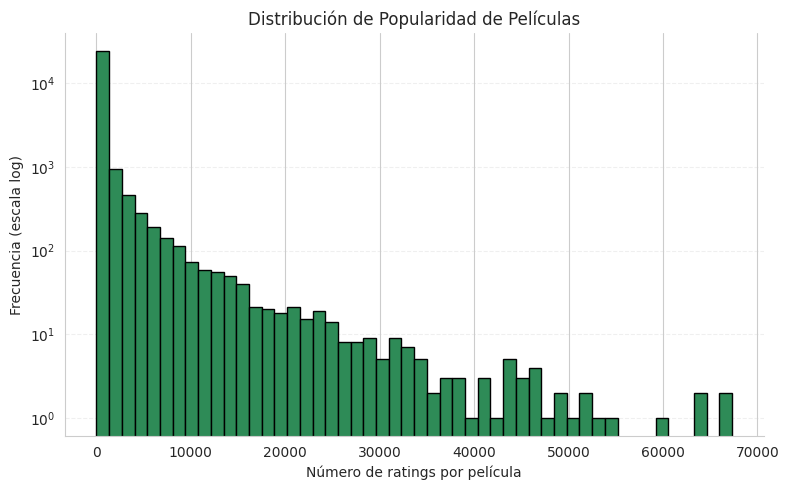

In [38]:
# 2. Histograma de distribución de popularidad de películas en escala logarítmica
plot_movie_popularity_distribution(movie_activity_pd, save_path="img/movie_popularity_dist.png")


✓ Gráfica guardada exitosamente en: img/movie_pop_vs_rating.png


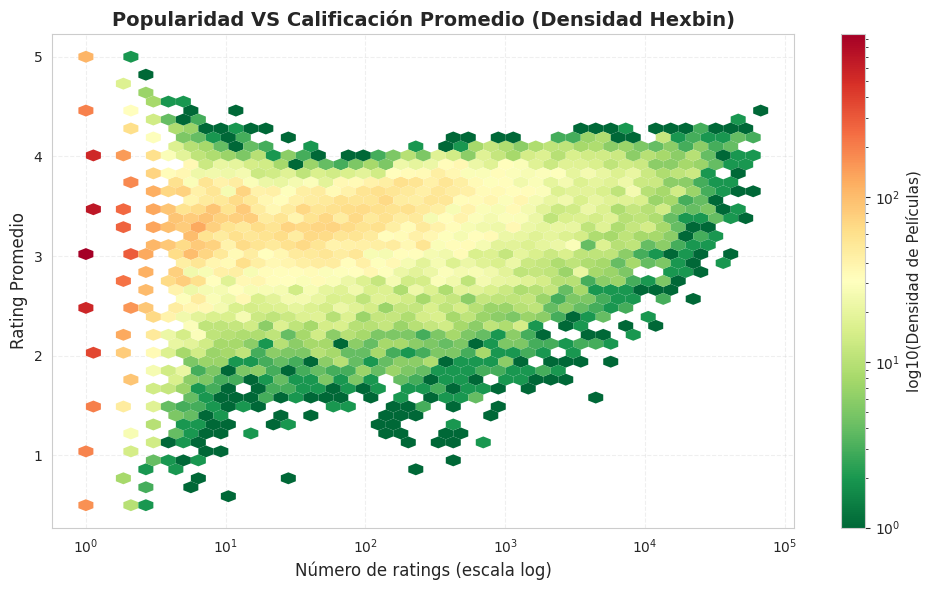


- La popularidad también sigue cola larga: pocas películas concentran gran parte de los ratings.
- El Hexbin Plot revela una relación de densidad mucho más clara: Existe una masa crítica de películas sin mucha popularidad, mientras que a mayor popularidad la calificación promedio suele estacionarse en valores moderados-altos, sin dispersarse a los extremos (ni pésimas ni perfectas).


In [39]:
# 3. Gráfico Hexbin de Densidad: Popularidad vs Calificación
plot_popularity_vs_rating_hexbin(movie_activity_pd, save_path="img/movie_pop_vs_rating.png")

print("\n- La popularidad también sigue cola larga: pocas películas concentran gran parte de los ratings.")
print("- El Hexbin Plot revela una relación de densidad mucho más clara: Existe una masa crítica de películas sin mucha popularidad, mientras que a mayor popularidad la calificación promedio suele estacionarse en valores moderados-altos, sin dispersarse a los extremos (ni pésimas ni perfectas).")

In [42]:
from source.utils.EDA import get_movie_quality_proportions, plot_top_quality_movies

# 4. Obtener las mejores películas en proporción pura de "Likes/Aprobación".
# Nota de Data Mining: Si ponemos min_ratings = 0, se cumple "estrictamente" que es independiente
# de la cantidad (y ganarían las de "1 voto" = 100%). Puse un filtro de 50 votos como heurística 
# para que veas películas reales, pero puedes cambiarlo a 0 o 1 si lo prefieres!

quality_pd = get_movie_quality_proportions(
    ratings_binary_df=ratings_binary,
    movies_df=movies_clean, 
    label_col='binary_rating',
    min_ratings=50,
    verbose=True
)

CALIDAD DE PELÍCULAS (Mínimo 50 ratings)
TOP 10 DE APRECIACIÓN:
  Lives of Others, The (Das leben der Anderen) (2006): 92.6% de aprobación (5720 ratings)
  Shawshank Redemption, The (1994): 91.9% de aprobación (63366 ratings)
  City of God (Cidade de Deus) (2002): 91.6% de aprobación (12937 ratings)
  Witness for the Prosecution (1957): 90.2% de aprobación (1620 ratings)
  Short Film About Love, A (Krótki film o milosci) (1988): 90.2% de aprobación (224 ratings)
  Rear Window (1954): 90.1% de aprobación (17449 ratings)
  Hunt, The (Jagten) (2012): 89.8% de aprobación (628 ratings)
  Dark Knight, The (2008): 89.8% de aprobación (20438 ratings)
  Yojimbo (1961): 89.7% de aprobación (3559 ratings)
  Band of Brothers (2001): 89.7% de aprobación (4305 ratings)



✓ Gráfica guardada exitosamente en: img/movie_quality_top.png


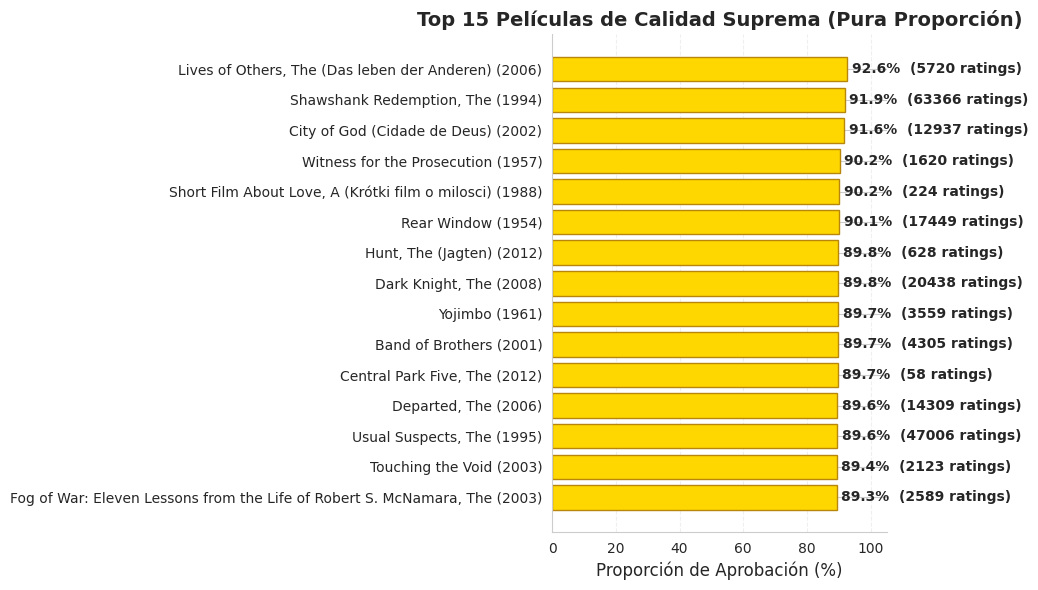


- A diferencia del conteo absoluto, ordenar por pura proporción nos permite descubrir verdaderas "Obras Maestras u Ocultas" que no necesariamente fueron Blockbusters comerciales.


In [43]:
plot_top_quality_movies(quality_pd, top_k=15, save_path="img/movie_quality_top.png")

print("\n- A diferencia del conteo absoluto, ordenar por pura proporción nos permite descubrir verdaderas \"Obras Maestras u Ocultas\" que no necesariamente fueron Blockbusters comerciales.")

### Paso 4: Análisis de géneros

In [48]:
from source.utils.EDA import get_genre_activity_data, plot_genre_distributions, plot_genre_bubble_chart

# 5. Análisis de Géneros: Oferta (Catálogo) vs Demanda (Ratings) + Análisis de Nichos de Calidad
print("Extrayendo datos de actividad por género...")
genres_combined_pd = get_genre_activity_data(movies_clean, ratings_clean, verbose=True)


Extrayendo datos de actividad por género...
ANÁLISIS DE GÉNEROS
VOLUMEN DE PELÍCULAS Y RATINGS (TOP 10 PERFILES):
  Drama: 8,857,853 ratings (Promedio: 3.67)
  Comedy: 7,502,234 ratings (Promedio: 3.43)
  Action: 5,614,208 ratings (Promedio: 3.44)
  Thriller: 5,313,506 ratings (Promedio: 3.51)
  Adventure: 4,380,351 ratings (Promedio: 3.50)
  Romance: 3,802,002 ratings (Promedio: 3.54)
  Crime: 3,298,335 ratings (Promedio: 3.67)
  Sci-Fi: 3,150,141 ratings (Promedio: 3.44)
  Fantasy: 2,111,403 ratings (Promedio: 3.51)
  Children: 1,669,249 ratings (Promedio: 3.41)


Generando Gráficos de Distribución de Géneros...

✓ Gráfica guardada exitosamente en: img/genre_distributions.png


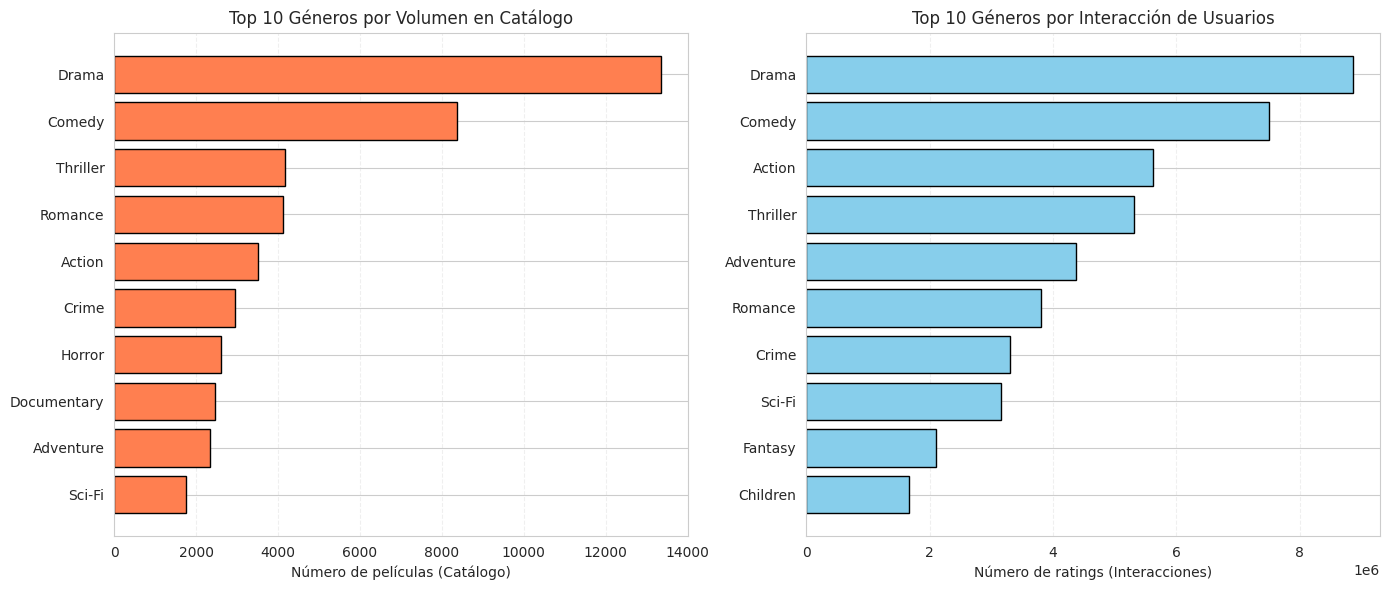

In [59]:
print("Generando Gráficos de Distribución de Géneros...")
plot_genre_distributions(genres_combined_pd,save_path = "img/genre_distributions.png")

Generando Mapeo Avanzado de Nichos de Género (Bubble Chart)...

✓ Gráfica guardada exitosamente en: img/genre_bubble_chart.png


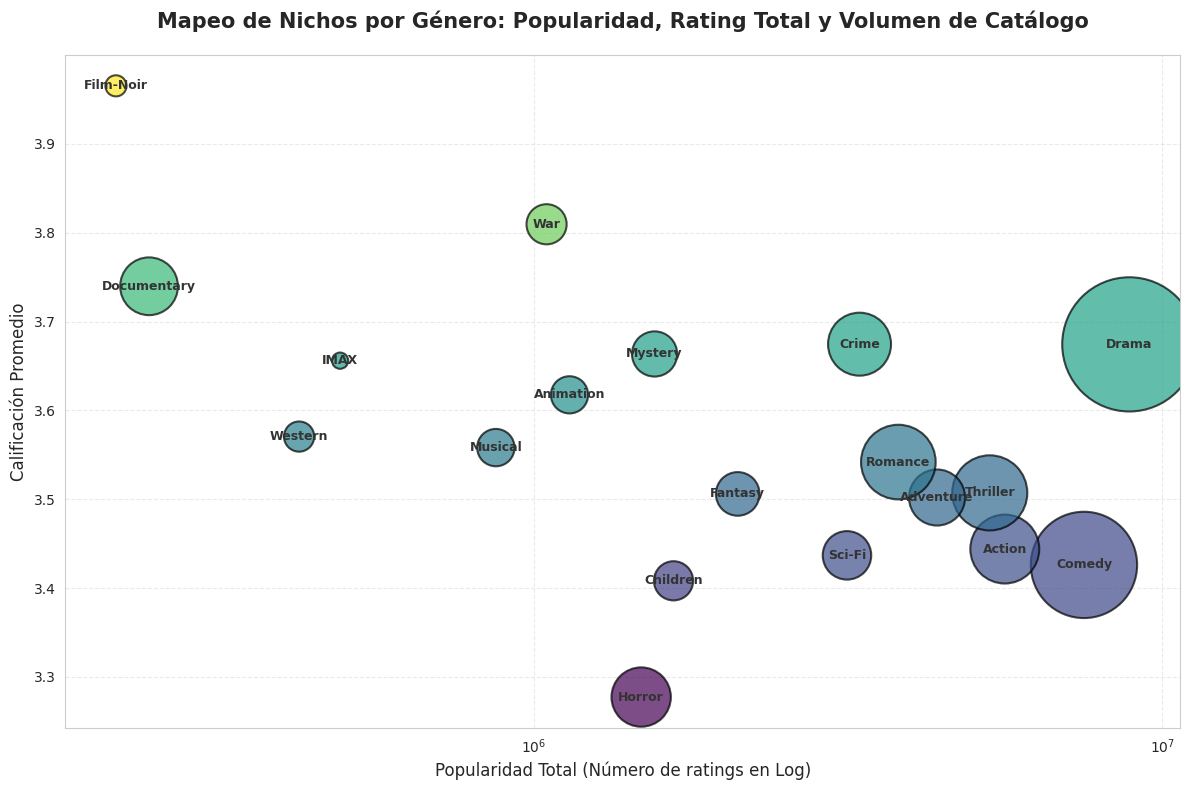


Insights de la Minería de Géneros:
- Oferta vs Demanda: Algunos géneros tienen muchas películas pero pocas interacciones (baja tracción).
- El Bubble Chart permite identificar en el cuadrante superior géneros de 'Nicho' (Altamente calificados, pocos ratings en volumen).


In [61]:
print("Generando Mapeo Avanzado de Nichos de Género (Bubble Chart)...")
plot_genre_bubble_chart(genres_combined_pd,show_legend=False,save_path="img/genre_bubble_chart.png")

print("\nInsights de la Minería de Géneros:")
print("- Oferta vs Demanda: Algunos géneros tienen muchas películas pero pocas interacciones (baja tracción).")
print("- El Bubble Chart permite identificar en el cuadrante superior géneros de 'Nicho' (Altamente calificados, pocos ratings en volumen).")

In [ ]:
import importlib
from source.utils import EDA
importlib.reload(EDA)


### Paso 5: Análisis de Sparsity (Densidad de la Matriz Usuario-Película)

In [64]:
from source.utils.EDA import get_sparsity_data, plot_matrix_sparsity

# Extraer datos de sparsity y mostrar las métricas
sparsity_metrics = get_sparsity_data(ratings_clean, verbose=True)



ANÁLISIS DE SPARSITY
Usuarios únicos: 138,493
Películas únicas: 26,744
Ratings totales: 20,000,263
Posibles ratings: 3,703,856,792

Densidad: 0.5400%
Sparsity: 99.4600%

Interpretación:
- Solo el 0.5400% de la matriz está lleno
- El 99.4600% de la matriz está vacía (no hay rating)
- En promedio, cada usuario ha calificado 144.41 de 26,744 películas
- En promedio, cada película ha sido calificada por 747.84 de 138,493 usuarios



✓ Gráfica guardada exitosamente en: img/matrix_sparsity.png


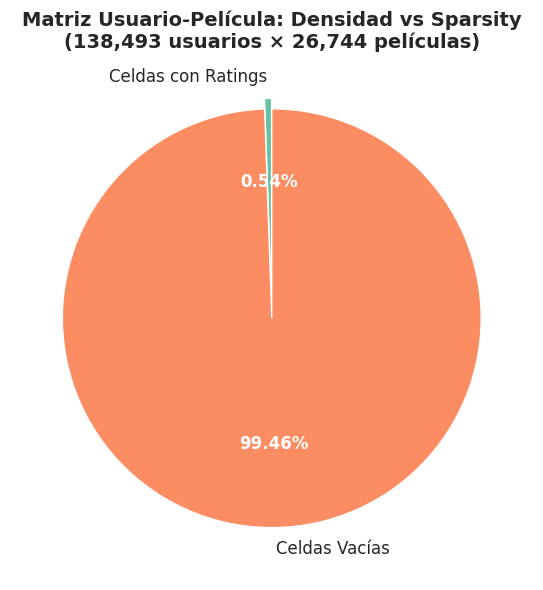

- El sistema opera sobre una matriz extremadamente dispersa, lo que justifica métodos aproximados como MinHash y LSH.
- La baja densidad implica que comparar todas las parejas de películas de forma exacta es costoso y poco escalable.


In [65]:
# Visualizar la proporción (Densidad vs Sparsity)
plot_matrix_sparsity(sparsity_metrics,save_path="img/matrix_sparsity.png")

print("- El sistema opera sobre una matriz extremadamente dispersa, lo que justifica métodos aproximados como MinHash y LSH.")
print("- La baja densidad implica que comparar todas las parejas de películas de forma exacta es costoso y poco escalable.")